# RBP-maps in a Jupyter notebook

This notebook walks through using the `rbp-maps` Python package directly (instead of the `plot_map` command line) to:

1. **Re-generate the RBFOX2 splicing maps** shown in the README (skipped exon step by step, then A3SS / A5SS / RI / MXE in one call each).
2. **Plot normalized read density over regions defined by a BED file**.

It uses the same data as [`reproducing_examples.md`](reproducing_examples.md): the HepG2 RBFOX2 eCLIP (`ENCSR987FTF`, replicate 1) and its size-matched input (`ENCSR799EKA`) from encodeproject.org, plus the annotation files shipped in `examples/`.

## Before you start

Install the package and register its environment as a Jupyter kernel (once):

```bash
conda env create -f environment.yml -n rbp-maps
conda activate rbp-maps
python -m pip install .
python -m pip install ipykernel
python -m ipykernel install --user --name rbp-maps --display-name "rbp-maps"
```

Then open this notebook with the **rbp-maps** kernel. Start Jupyter from a shell where the `rbp-maps` environment is active, so that `samtools`, `bedtools` and `bedGraphToBigWig` are on `PATH`.

## 0. Configuration

`REPO` is your clone of this repository (the notebook lives in `REPO/documentation`). `WORK` is where downloads and outputs are written; if you already followed `reproducing_examples.md`, point `WORK` at that same directory and the download/filter steps below are skipped.

In [1]:
import os
import shutil
import subprocess
from collections import OrderedDict
from pathlib import Path

REPO = Path(os.environ.get("RBPMAPS_REPO", "..")).resolve()
WORK = Path(os.environ.get("RBPMAPS_WORK", "rbp-maps-repro")).resolve()

CLIP = WORK / "clip"                  # BAMs and bigWigs
OUT = WORK / "notebook_outputs"       # everything this notebook writes
SPLICING = REPO / "examples" / "splicing_data"
GENOME = REPO / "examples" / "data" / "hg19.chrom.sizes"

for d in (CLIP, OUT):
    d.mkdir(parents=True, exist_ok=True)

for tool in ("samtools", "bedtools", "bedGraphToBigWig"):
    assert shutil.which(tool), "{} is not on PATH".format(tool)
assert GENOME.exists(), "cannot find {}; check REPO".format(GENOME)
print("REPO:", REPO)
print("WORK:", WORK)

REPO: <REPO>
WORK: <WORK>


## 1. Get the reads (read 2 only)

The ENCODE BAM files are paired-end and contain **both** mates. RBP-maps expects BAM files that come from paired-end data but contain **read 2 only** (in eCLIP, read 2 is the mate whose 5' end marks the crosslink site, and it maps to the same strand as the RNA). `samtools view -f 128` keeps only the alignments flagged "second in pair".

| | ENCODE accession | read-2-only file made here |
|---|---|---|
| RBFOX2 eCLIP, HepG2, rep 1 (hg19) | `ENCFF994WPX` | `ENCFF994WPX.r2.bam` |
| size-matched input (hg19) | `ENCFF590UCY` | `ENCFF590UCY.r2.bam` |

In [2]:
def fetch_r2_bam(accession):
    # Download an ENCODE BAM, keep read 2 only (-f 128), and index it.
    full = CLIP / (accession + ".bam")
    r2 = CLIP / (accession + ".r2.bam")
    if not r2.exists():
        if not full.exists():
            url = "https://www.encodeproject.org/files/{0}/@@download/{0}.bam".format(accession)
            subprocess.check_call(["curl", "-sSL", "-o", str(full), url])
        subprocess.check_call(["samtools", "view", "-f", "128", "-b", "-o", str(r2), str(full)])
    if not Path(str(r2) + ".bai").exists():
        subprocess.check_call(["samtools", "index", str(r2)])
    return r2

IP_BAM = fetch_r2_bam("ENCFF994WPX")
INPUT_BAM = fetch_r2_bam("ENCFF590UCY")

for bam in (IP_BAM, INPUT_BAM):
    n = subprocess.check_output(["samtools", "view", "-c", str(bam)]).decode().strip()
    print(bam.name, n, "reads")

ENCFF994WPX.r2.bam 4275451 reads


ENCFF590UCY.r2.bam 3765762 reads


Expected read counts: **4,275,451** (IP) and **3,765,762** (input).

## 2. Make RPM-normalized, strand-specific bigWigs

Density maps read signal from two bigWig files per BAM (`*.norm.pos.bw`, `*.norm.neg.bw`). `plot_map` builds them automatically; here we call the same function directly.

`direction="f"` matters: a read-2-only eCLIP BAM is *forward*-stranded (reads map to the strand of the RNA). The default (`"r"`) swaps the strands and is only correct for BAMs whose reads are antisense to the RNA.

In [3]:
from maps import plot_map

def bigwigs_for(bam):
    pos = str(bam).replace(".bam", ".norm.pos.bw")
    neg = str(bam).replace(".bam", ".norm.neg.bw")
    plot_map.ensure_density_bigwigs(
        bam=str(bam), pos_bw=pos, neg_bw=neg, genome_file=str(GENOME),
        direction="f", makebigwigfiles_cmd=None, makebigwigfiles_extra_args="",
    )
    return pos, neg

IP_POS, IP_NEG = bigwigs_for(IP_BAM)
INPUT_POS, INPUT_NEG = bigwigs_for(INPUT_BAM)
print(IP_POS, IP_NEG, INPUT_POS, INPUT_NEG, sep="\n")

<WORK>/clip/ENCFF994WPX.r2.norm.pos.bw
<WORK>/clip/ENCFF994WPX.r2.norm.neg.bw
<WORK>/clip/ENCFF590UCY.r2.norm.pos.bw
<WORK>/clip/ENCFF590UCY.r2.norm.neg.bw


## 3. Load the signal

A `ReadDensity` object wraps the two bigWigs plus the BAM (the BAM is used for the read count that defines the pseudocount, i.e. the RPM value of a single read).

In [4]:
import density.ReadDensity
import density.normalization_functions as norm
from density import Map

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ip = density.ReadDensity.ReadDensity(pos=IP_POS, neg=IP_NEG, bam=str(IP_BAM))
inp = density.ReadDensity.ReadDensity(pos=INPUT_POS, neg=INPUT_NEG, bam=str(INPUT_BAM))

print("IP mapped reads:   ", ip.total_mapped(), " pseudocount (RPM of 1 read):", ip.pseudocount())
print("input mapped reads:", inp.total_mapped(), " pseudocount (RPM of 1 read):", inp.pseudocount())

# signal over an arbitrary window: one RPM value per base, 5'->3' on the requested strand
np.round(ip.values("chr7", 4757099, 4757109, "+"), 2)

IP mapped reads:    4275451  pseudocount (RPM of 1 read): 0.2338934535795171
input mapped reads: 3765762  pseudocount (RPM of 1 read): 0.26555050478495457


array([21.05, 22.69, 22.22, 24.79, 26.43, 28.07, 29.24, 31.34, 31.81,
       33.91])

# Part 1 - Re-generate the splicing maps

## 4. Skipped exon map, step by step

**Annotations.** A map overlays one line per annotation file. The `OrderedDict` maps each file to its format:

- `rmats` - rMATS `*.MATS.JunctionCountOnly.txt` rows (here: exons included / excluded upon RBFOX2 knockdown, from ENCODE `ENCSR767LLP`)
- `tab` - the native-exon background sets derived from all ENCODE HepG2 control RNA-seq

The order sets the line colors (first = red, second = blue, then background colors).

In [5]:
se_dir = SPLICING / "se_splice_data"
se_files = [
    ("RBFOX2-BGHLV26-HepG2.set26-included-upon-knockdown", "rmats"),
    ("RBFOX2-BGHLV26-HepG2.set26-excluded-upon-knockdown", "rmats"),
    ("HepG2_constitutive_exons", "tab"),
    ("HepG2_natively_included_cassette_exons", "tab"),
    ("HepG2_natively_excluded_cassette_exons", "tab"),
    ("HepG2_native_cassette_exons_all", "tab"),
]
se_annotations = OrderedDict((str(se_dir / name), fmt) for name, fmt in se_files)

se_test = list(se_annotations)[:2]        # the two knockdown-responsive sets (--testnums 0 1)
se_background = list(se_annotations)[5]   # all native cassette exons            (--bgnum 5)

for path in se_annotations:
    with open(path) as f:
        print("{:>6} events  {}".format(sum(1 for _ in f) - 1, os.path.basename(path)))

   113 events  RBFOX2-BGHLV26-HepG2.set26-included-upon-knockdown
   138 events  RBFOX2-BGHLV26-HepG2.set26-excluded-upon-knockdown
  7351 events  HepG2_constitutive_exons
  1137 events  HepG2_natively_included_cassette_exons
   357 events  HepG2_natively_excluded_cassette_exons
  1805 events  HepG2_native_cassette_exons_all


**Build the map object.** The normalization function corresponds to `--normalization_level`:

| level | function | meaning |
|---|---|---|
| 0 | `norm.get_density` | IP density only |
| 1 (default) | `norm.per_region_subtract_and_normalize` | IP minus input, then each event scaled to sum to 1 |
| 2 | `norm.read_entropy` | entropy-normalized IP over input |
| 3 | `norm.get_input` | input density only |
| 4 | `norm.normalize_and_per_region_subtract` | scale each event first, then subtract |

In [6]:
(OUT / "se").mkdir(exist_ok=True)
se_png = str(OUT / "se" / "RBFOX2-SE.png")   # use .svg for an editable vector figure

se_map = Map.SkippedExon(
    ip, inp, se_png, norm.per_region_subtract_and_normalize,
    se_annotations, exon_offset=50, intron_offset=300,
    min_density_threshold=0, conf=0.95,
)

se_map.create_matrices()    # raw RPM density per event, for IP and input
se_map.normalize_matrix()   # apply the normalization function
se_map.create_lines()       # outlier removal (keep 95%) and per-position means

**Look at the matrices.** Rows are events, columns are positions. A skipped-exon map has 1,400 columns: four splice-site windows of 350 nt each (50 nt of exon + 300 nt of intron):

| columns | window |
|---|---|
| 0-349 | upstream exon 3' end (50 nt) then downstream intron (300 nt) |
| 350-699 | intron (300 nt) then skipped exon 5' end (50 nt) |
| 700-1049 | skipped exon 3' end (50 nt) then intron (300 nt) |
| 1050-1399 | intron (300 nt) then downstream exon 5' end (50 nt) |

`-1` in a raw matrix marks positions that fall outside the feature (for example an exon shorter than 50 nt).

In [7]:
excluded = se_test[1]
print("raw IP matrix:    ", se_map.raw_matrices["ip"][excluded].shape)
print("raw input matrix: ", se_map.raw_matrices["input"][excluded].shape)
print("normalized matrix:", se_map.norm_matrices[excluded].shape)

normed = se_map.norm_matrices[excluded].copy()
normed.index = [row.split("\t")[2] for row in normed.index]   # gene symbol, for display only
normed.iloc[:5, 695:705]

raw IP matrix:     (138, 1400)
raw input matrix:  (138, 1400)
normalized matrix: (138, 1400)


,695,696,697,698,699,700,701,702,703,704
UBE2J2,0.000231,0.000231,0.000231,0.000231,0.000231,0.000000,0.000000,0.000000,0.000000,0.000000
ARHGEF10L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EPB41,0.000330,0.000000,0.000000,0.000000,0.000000,-0.000374,-0.000374,-0.000045,-0.000045,-0.000045
SRSF4,-0.001226,-0.001226,-0.001226,-0.001226,-0.001226,-0.000613,-0.000613,-0.000613,-0.000613,-0.001226
PHC2,-0.000041,-0.000041,-0.000041,0.000265,0.000265,0.000306,0.000306,0.000306,0.000306,0.000306


**Significance.** With `permutation`, the background set is randomly subsampled 1,000 times to the size of each test set; the 0.5th-99.5th percentile band of those subsamples is drawn around the background line. This is the slow step (about 10 minutes for this map). Use `"zscore"`, `"ks"` or `"mannwhitneyu"` for a quick look.

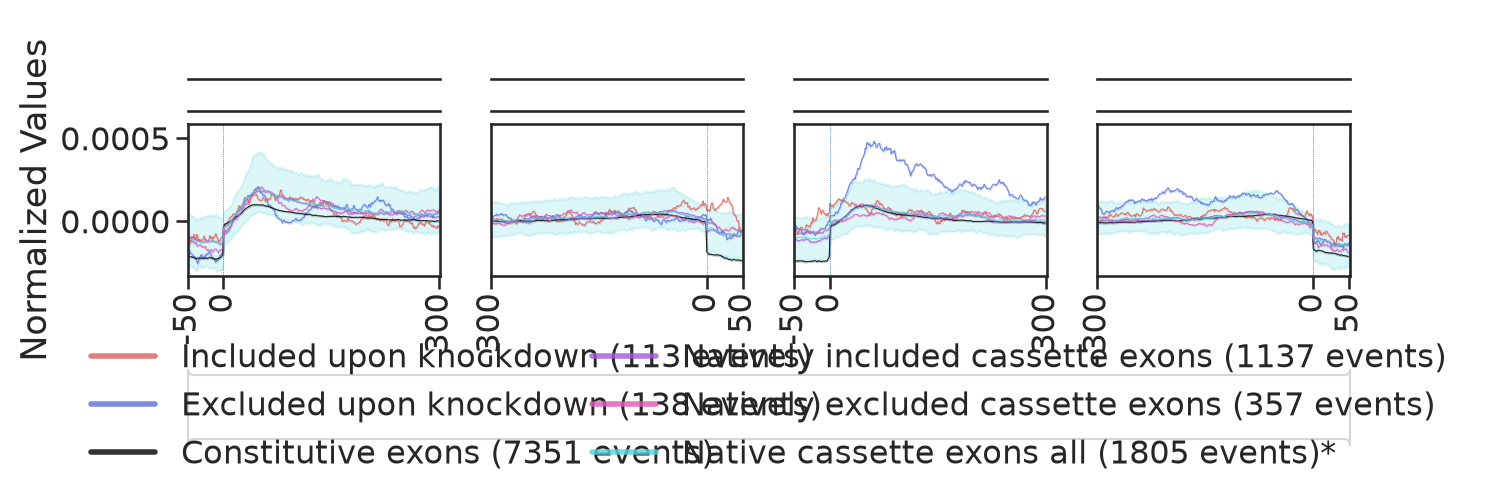

In [8]:
se_map.set_background_and_calculate_significance(se_test, se_background, "permutation")
se_map.write_intermediates_to_csv()   # matrices and means, next to the figure
se_map.plot(se_test)
plt.close("all")   # the figure is saved to se_png; show the saved file

display(Image(se_png))

RBFOX2 binding is enriched in the intron **downstream** of exons that are *excluded upon knockdown* (exons RBFOX2 normally activates), the expected position-dependent pattern.

**Intermediate files** written next to the figure (prefix = figure name without extension):

| suffix | content |
|---|---|
| `.<annotation>.ip.raw_density.txt` / `.input.raw_density.txt` | RPM density per event and position (CSV) |
| `.<annotation>.normed_matrix.txt` | normalized matrix (CSV) |
| `.<annotation>.means.txt` | outlier-removed mean per position, i.e. the plotted line |
| `.<annotation>.ip.sum_coverage.txt` / `.input.sum_coverage.txt` | summed density per event |
| `.png.<background>.<test>.randsample.tsv` | permutation means (one row per iteration) |

In [9]:
sorted(p.name for p in (OUT / "se").iterdir())[:8]

['RBFOX2-SE.HepG2_constitutive_exons.input.raw_density.txt',
 'RBFOX2-SE.HepG2_constitutive_exons.input.sum_coverage.txt',
 'RBFOX2-SE.HepG2_constitutive_exons.ip.raw_density.txt',
 'RBFOX2-SE.HepG2_constitutive_exons.ip.sum_coverage.txt',
 'RBFOX2-SE.HepG2_constitutive_exons.means.txt',
 'RBFOX2-SE.HepG2_constitutive_exons.normed_matrix.txt',
 'RBFOX2-SE.HepG2_native_cassette_exons_all.input.raw_density.txt',
 'RBFOX2-SE.HepG2_native_cassette_exons_all.input.sum_coverage.txt']

**Plot it yourself.** Every line on the map is a `LineObject` in `se_map.lines`; `line.means` is the plotted curve, `line.error_pos` / `line.error_neg` the band.

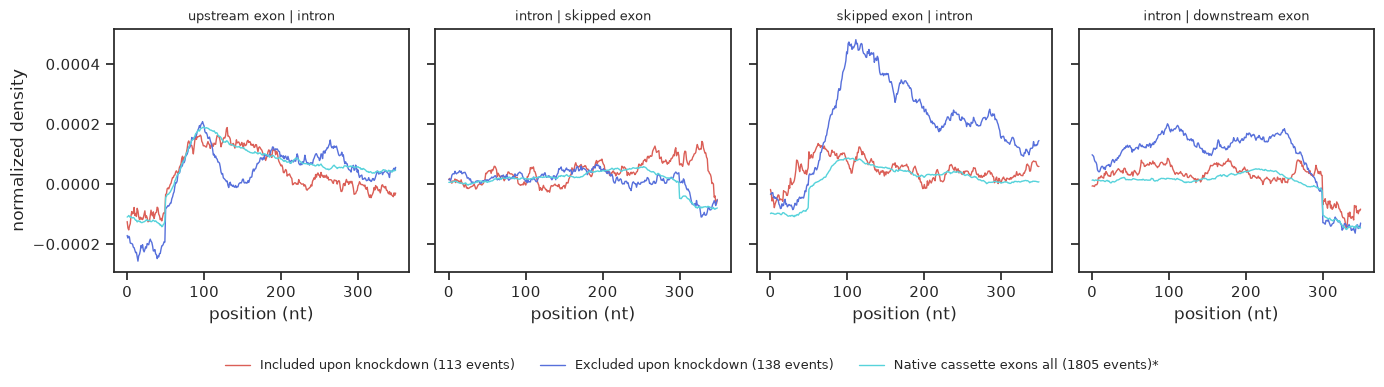

In [10]:
import seaborn as sns

def plain_style():
    # the package plots with a large seaborn context; use a normal one for our own figures
    sns.set_theme(context="notebook", style="ticks")

plain_style()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
titles = ["upstream exon | intron", "intron | skipped exon", "skipped exon | intron", "intron | downstream exon"]

for line in se_map.lines:
    if line.annotation_src_file not in se_test + [se_background]:
        continue
    means = np.array(line.means)
    for i, ax in enumerate(axes):
        ax.plot(means[i * 350:(i + 1) * 350], color=line.color, lw=1, label=line.label if i == 0 else None)

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("position (nt)")
axes[0].set_ylabel("normalized density")
fig.legend(loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.12), fontsize=9)
fig.tight_layout()
plt.show()

## 5. The other event types in one call each

`plot_map.run_make_density` is what the command line calls after parsing its arguments; it runs the same five steps as above for any event type.

In [11]:
def splice_map(event, files, testnums, bgnum, sigtest):
    subdir = SPLICING / "{}_splice_data".format(event)
    annotations = OrderedDict((str(subdir / name), fmt) for name, fmt in files)
    paths = list(annotations)
    (OUT / event).mkdir(exist_ok=True)
    out = str(OUT / event / "RBFOX2-{}.png".format(event.upper()))
    plot_map.run_make_density(
        out, IP_POS, IP_NEG, str(IP_BAM), INPUT_POS, INPUT_NEG, str(INPUT_BAM),
        norm.per_region_subtract_and_normalize, event, 50, 300, 0.95,
        annotations, [paths[i] for i in testnums],
        paths[bgnum] if bgnum is not None else None, sigtest, False,
    )
    plt.close("all")
    return out

def alt_ss_files(event):
    tag = event.upper()
    return [
        ("RBFOX2-BGHLV26-HepG2.set26.{}longer-isoform-included-upon-knockdown".format(tag), "rmats"),
        ("RBFOX2-BGHLV26-HepG2.set26.{}shorter-isoform-included-upon-knockdown".format(tag), "rmats"),
        ("HepG2-all-native-{}-events".format(event), "tab"),
        ("HepG2-shorter-isoform-in-majority-of-controls", "tab"),
        ("HepG2-mixed-psi-isoform-in-majority-of-controls", "tab"),
        ("HepG2-longer-isoform-in-majority-of-controls", "tab"),
    ]

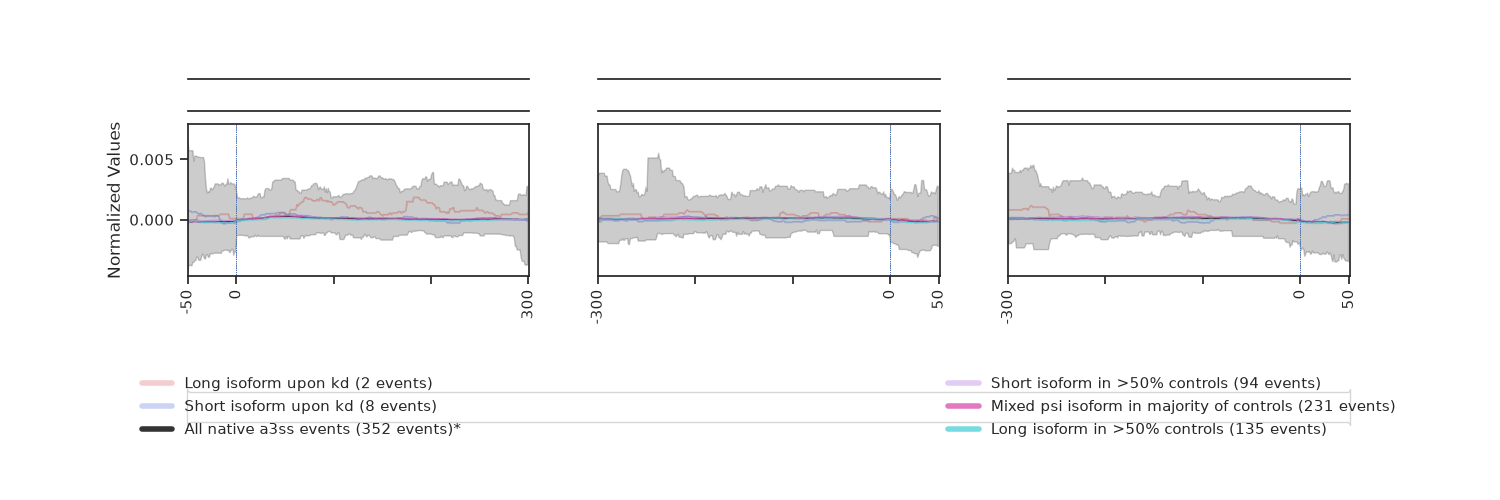

In [12]:
display(Image(splice_map("a3ss", alt_ss_files("a3ss"), testnums=[0, 1], bgnum=2, sigtest="permutation")))

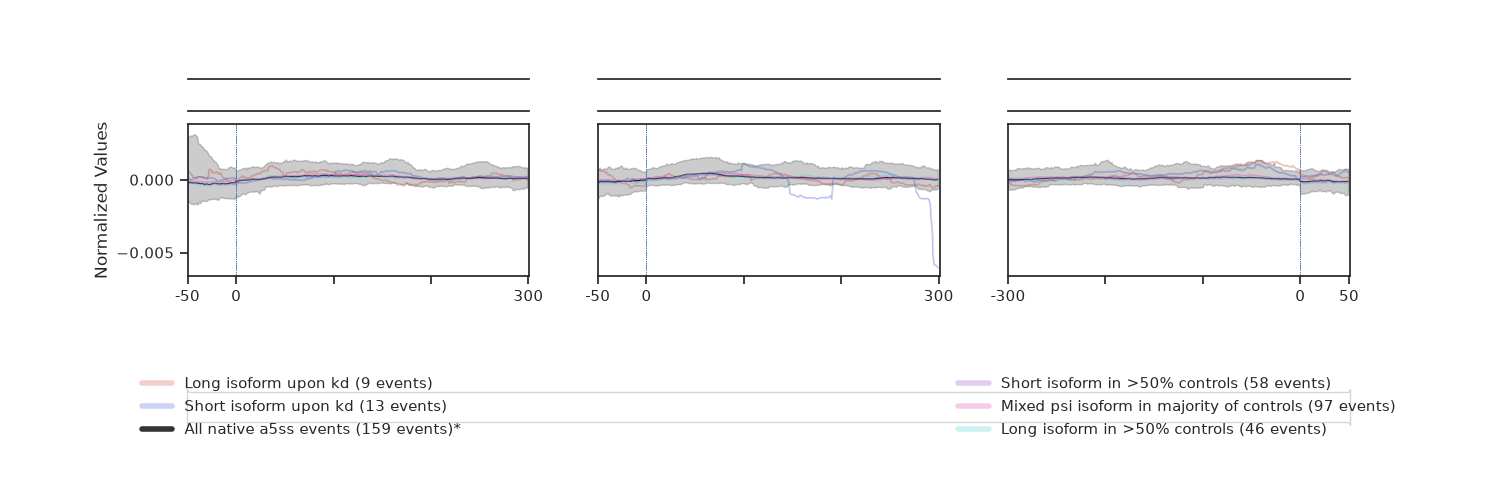

In [13]:
display(Image(splice_map("a5ss", alt_ss_files("a5ss"), testnums=[0, 1], bgnum=2, sigtest="permutation")))

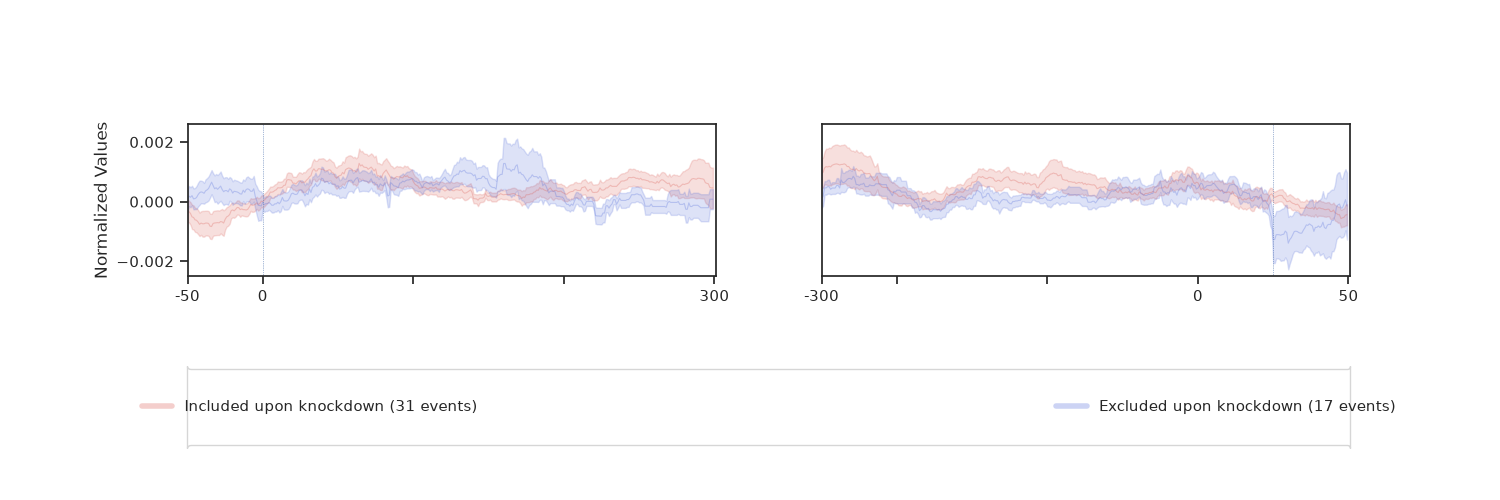

In [14]:
display(Image(splice_map("ri", [
    ("RBFOX2-BGHLV26-HepG2.set26-included-upon-knockdown", "rmats"),
    ("RBFOX2-BGHLV26-HepG2.set26-excluded-upon-knockdown", "rmats"),
], testnums=[], bgnum=None, sigtest="permutation")))

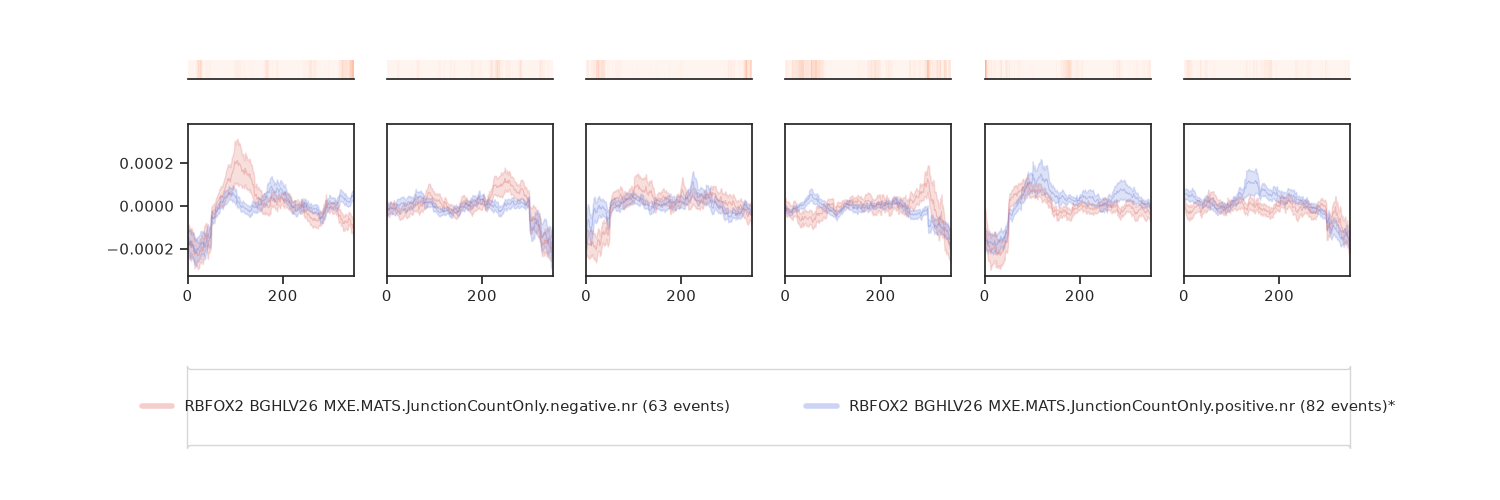

In [15]:
display(Image(splice_map("mxe", [
    ("RBFOX2-BGHLV26-HepG2-MXE.MATS.JunctionCountOnly.negative.nr.txt", "rmats"),
    ("RBFOX2-BGHLV26-HepG2-MXE.MATS.JunctionCountOnly.positive.nr.txt", "rmats"),
], testnums=[0], bgnum=1, sigtest="ks")))

Lines drawn faded come from annotation sets with fewer than 100 events (RBFOX2 knockdown changes only a handful of A3SS/A5SS/RI events), so treat those curves as noisy.

# Part 2 - Normalized read density over BED-defined regions

The `bed` event type plots density over any regions you define, with no splicing model. Each annotation is a tab-separated **BED6** file (`chrom  start  end  name  score  strand`; extra columns are ignored, and the strand column is required because signal is read strand-specifically and oriented 5'->3').

Two layouts are supported:

- **Anchored** (section 6): all regions have the same length, typically 1-nt anchor points (a splice site, a start codon, a peak summit) extended by `upstream_offset` / `downstream_offset`.
- **Scaled** (section 7): regions of different lengths, each rescaled to 100 bins with `scale=True`.

## 6. Anchored regions

As a worked example we build BED files of **5' splice sites of skipped exons** (the last exonic base, just before the downstream intron) for three sets: exons excluded upon RBFOX2 knockdown, exons included upon knockdown, and all native cassette exons. Any BED6 file of your own works the same way.

In [16]:
BED = OUT / "bed"
BED.mkdir(exist_ok=True)

def five_prime_ss(chrom, start, end, strand, name):
    # 1-nt interval at the last base of the exon
    if strand == "+":
        return [chrom, end - 1, end, name, 0, strand]
    return [chrom, start, start + 1, name, 0, strand]

def rmats_to_anchor_bed(rmats_file, out_bed):
    df = pd.read_csv(rmats_file, sep="\t")
    rows = [five_prime_ss(r["chr"], r["exonStart_0base"], r["exonEnd"], r["strand"], r["geneSymbol"])
            for _, r in df.iterrows()]
    pd.DataFrame(rows).to_csv(out_bed, sep="\t", header=False, index=False)
    return str(out_bed)

def native_to_anchor_bed(tab_file, out_bed):
    # 'annotation' looks like chr1|-|...; 'skipped_exon' is start-end
    df = pd.read_csv(tab_file, sep="\t")
    rows = []
    for _, r in df.iterrows():
        chrom, strand = r["annotation"].split("|")[:2]
        start, end = (int(x) for x in r["skipped_exon"].split("-"))
        rows.append(five_prime_ss(chrom, start, end, strand, "native"))
    pd.DataFrame(rows).to_csv(out_bed, sep="\t", header=False, index=False)
    return str(out_bed)

bed_excluded = rmats_to_anchor_bed(se_dir / "RBFOX2-BGHLV26-HepG2.set26-excluded-upon-knockdown",
                                   BED / "excluded-upon-knockdown.5pss.bed")
bed_included = rmats_to_anchor_bed(se_dir / "RBFOX2-BGHLV26-HepG2.set26-included-upon-knockdown",
                                   BED / "included-upon-knockdown.5pss.bed")
bed_native = native_to_anchor_bed(se_dir / "HepG2_native_cassette_exons_all",
                                  BED / "native-cassette-exons.5pss.bed")

pd.read_csv(bed_excluded, sep="\t", header=None).head()

,0,1,2,3,4,5
0,chr1,1206889,1206890,UBE2J2,0,-
1,chr1,17961056,17961057,ARHGEF10L,0,+
2,chr1,29386995,29386996,EPB41,0,+
3,chr1,29476614,29476615,SRSF4,0,-
4,chr1,33800766,33800767,PHC2,0,-


`Map.Bed` takes the same arguments as the splicing maps, with `upstream_offset` / `downstream_offset` instead of exon/intron offsets. Here each anchor is extended 50 nt upstream (into the exon) and 300 nt downstream (into the intron), giving 351 columns.

{'included-upon-knockdown.5pss.bed': (113, 351), 'excluded-upon-knockdown.5pss.bed': (138, 351), 'native-cassette-exons.5pss.bed': (1805, 351)}


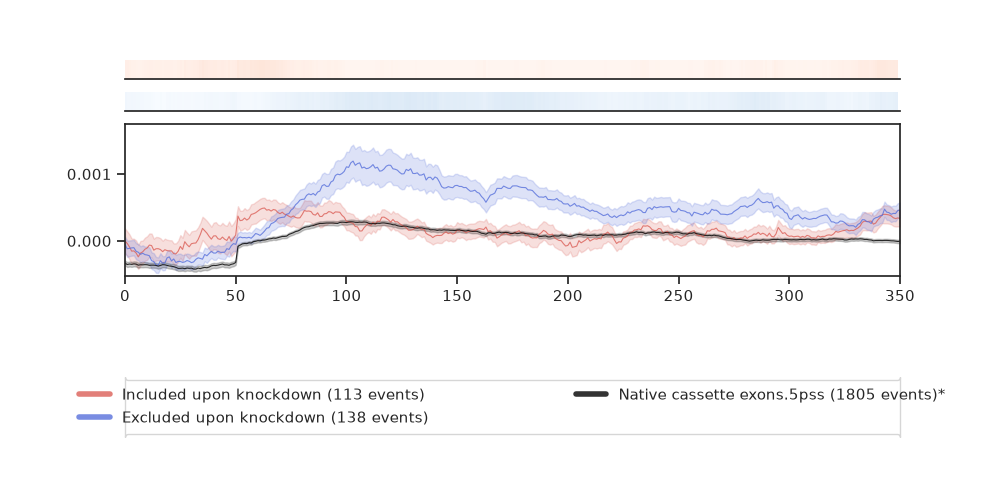

In [17]:
bed_annotations = OrderedDict([
    (bed_included, "bed"),
    (bed_excluded, "bed"),
    (bed_native, "bed"),
])
bed_png = str(BED / "RBFOX2-5pss.png")

bed_map = Map.Bed(
    ip, inp, bed_png, norm.per_region_subtract_and_normalize,
    bed_annotations, upstream_offset=50, downstream_offset=300,
    min_density_threshold=0, conf=0.95, scale=False,
)
bed_map.create_matrices()
bed_map.normalize_matrix()
bed_map.create_lines()
bed_map.set_background_and_calculate_significance([bed_included, bed_excluded], bed_native, "zscore")
bed_map.write_intermediates_to_csv()
bed_map.plot([bed_included, bed_excluded])
plt.close("all")

print({os.path.basename(k): v.shape for k, v in bed_map.norm_matrices.items()})
display(Image(bed_png))

The same thing from the command line (`--exon_offset` is the upstream offset and `--intron_offset` the downstream offset for `bed` events):

```bash
plot_map --event bed \
  --ip clip/ENCFF994WPX.r2.bam --input clip/ENCFF590UCY.r2.bam \
  --annotations included-upon-knockdown.5pss.bed excluded-upon-knockdown.5pss.bed native-cassette-exons.5pss.bed \
  --annotation_type bed bed bed \
  --exon_offset 50 --intron_offset 300 \
  --normalization_level 1 --testnums 0 1 --bgnum 2 --sigtest zscore \
  --output RBFOX2-5pss.png
```

A custom plot of the same lines, with the x axis relative to the splice site and the standard-error band:

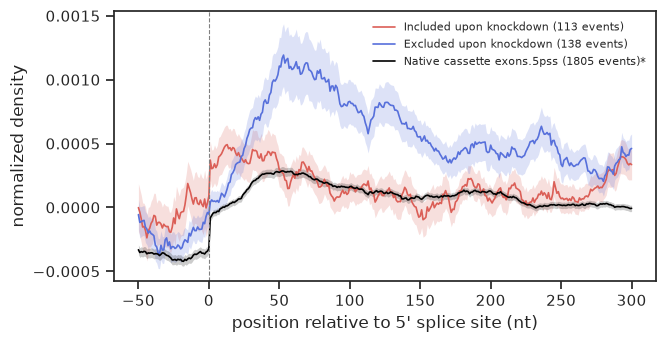

In [18]:
plain_style()
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(-50, 301)
for line in bed_map.lines:
    ax.plot(x, line.means, color=line.color, lw=1.2, label=line.label)
    ax.fill_between(x, line.error_neg, line.error_pos, color=line.color, alpha=0.2, lw=0)
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("position relative to 5' splice site (nt)")
ax.set_ylabel("normalized density")
ax.legend(frameon=False, fontsize=8)
plt.show()

To plot **RPM read density without input normalization**, swap the normalization function for `norm.get_density` (IP only) or `norm.get_input` (input only); nothing else changes.

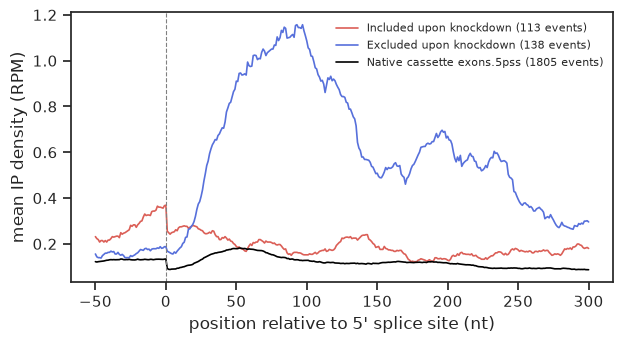

In [19]:
rpm_map = Map.Bed(
    ip, inp, str(BED / "RBFOX2-5pss.ip_rpm.png"), norm.get_density,
    bed_annotations, upstream_offset=50, downstream_offset=300, conf=0.95,
)
rpm_map.create_matrices()
rpm_map.normalize_matrix()
rpm_map.create_lines()

plain_style()
fig, ax = plt.subplots(figsize=(7, 3.5))
for line in rpm_map.lines:
    ax.plot(x, line.means, color=line.color, lw=1.2, label=line.label)
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("position relative to 5' splice site (nt)")
ax.set_ylabel("mean IP density (RPM)")
ax.legend(frameon=False, fontsize=8)
plt.show()

## 7. Regions of different lengths (scaled)

When the BED intervals differ in length, pass `scale=True` (`--scale` on the command line): each region is rescaled to 100 bins before averaging, so the x axis is percent of region length. Here the regions are the 300 nt of intron downstream of each skipped exon, clipped at the next exon so their lengths vary.

region lengths: {'min': 148.0, '50%': 300.0, 'max': 300.0}


{'included-upon-knockdown.downstream-intron.bed': (113, 100), 'excluded-upon-knockdown.downstream-intron.bed': (138, 100)}


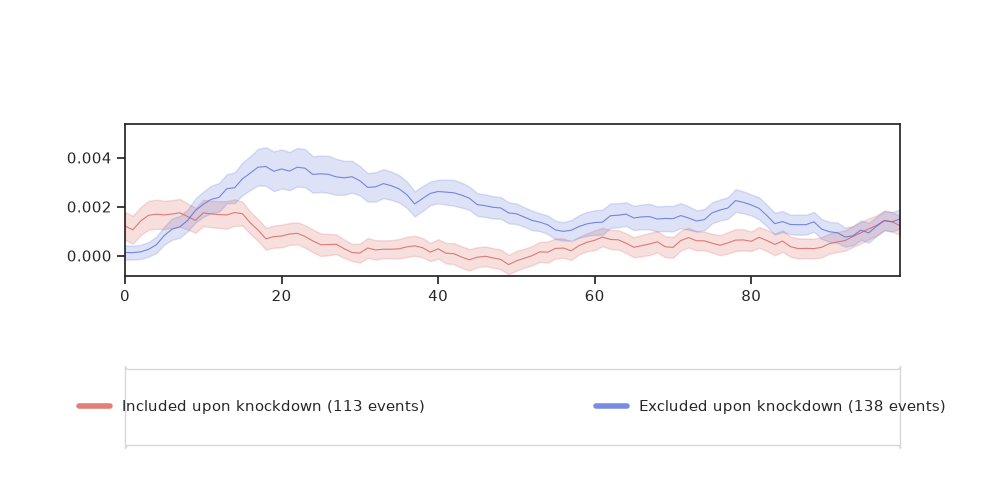

In [20]:
def rmats_to_downstream_intron_bed(rmats_file, out_bed, max_len=300):
    df = pd.read_csv(rmats_file, sep="\t")
    rows = []
    for _, r in df.iterrows():
        if r["strand"] == "+":
            start, end = r["exonEnd"], min(r["exonEnd"] + max_len, r["downstreamES"])
        else:
            start, end = max(r["exonStart_0base"] - max_len, r["upstreamEE"]), r["exonStart_0base"]
        rows.append([r["chr"], start, end, r["geneSymbol"], 0, r["strand"]])
    pd.DataFrame(rows).to_csv(out_bed, sep="\t", header=False, index=False)
    return str(out_bed)

intron_excluded = rmats_to_downstream_intron_bed(
    se_dir / "RBFOX2-BGHLV26-HepG2.set26-excluded-upon-knockdown", BED / "excluded-upon-knockdown.downstream-intron.bed")
intron_included = rmats_to_downstream_intron_bed(
    se_dir / "RBFOX2-BGHLV26-HepG2.set26-included-upon-knockdown", BED / "included-upon-knockdown.downstream-intron.bed")

lengths = pd.read_csv(intron_excluded, sep="\t", header=None)
print("region lengths:", (lengths[2] - lengths[1]).describe()[["min", "50%", "max"]].to_dict())

scaled_png = str(BED / "RBFOX2-downstream-intron.scaled.png")
scaled_map = Map.Bed(
    ip, inp, scaled_png, norm.per_region_subtract_and_normalize,
    OrderedDict([(intron_included, "bed"), (intron_excluded, "bed")]),
    upstream_offset=0, downstream_offset=0, conf=0.95, scale=True,
)
scaled_map.create_matrices()
scaled_map.normalize_matrix()
scaled_map.create_lines()
scaled_map.write_intermediates_to_csv()
scaled_map.plot([])
plt.close("all")

print({os.path.basename(k): v.shape for k, v in scaled_map.norm_matrices.items()})
display(Image(scaled_png))

## Notes

- **Strand.** If a map looks like noise, check the bigWig strand first: for a read-2-only eCLIP BAM, `*.norm.pos.bw` must hold reads mapped to the `+` strand (`direction="f"`).
- **Event counts.** Lines from fewer than 100 events are drawn faded. ENCODE maps used a minimum of 100 events per annotation.
- **Outliers.** `conf=0.95` drops the most extreme 5% of events at every position before averaging; the saved `normed_matrix.txt` is *before* outlier removal.
- **Memory.** Matrices are held in memory (events x positions, for IP and input). Hundreds of thousands of regions need tens of GB.
- **Peak maps.** For peak-overlap maps, use `density.Peak.Peak(peaks="peaks.bb")` in place of both `ReadDensity` objects and `norm.get_density` as the normalization function (see `plot_map.run_make_peak`).